In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

In [5]:
df = pd.read_csv("table_group_params.csv")
rproj_fit_mult=df.rproj_fit_mult.to_numpy()
vproj_fit_mult=df.vproj_fit_mult.to_numpy()
vproj_fit_offset=df.vproj_fit_offset.to_numpy()
gdrproj_fit_mult=df.gd_rproj_fit_mult.to_numpy()
gdvproj_fit_mult=df.gd_vproj_fit_mult.to_numpy()
gdvproj_fit_offset=df.gd_vproj_fit_offset.to_numpy()
labels=["({a:d},{b:d},{c:d},{d:d},{e:d},{f:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii], d=gdrproj_fit_mult[ii], e=gdvproj_fit_mult[ii], f=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
labels_for_giant_params=["({a:d}, {b:d}, {c:d})".format(a=rproj_fit_mult[ii], b=vproj_fit_mult[ii], c=vproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'labels_giant_params']=labels_for_giant_params

dwarflabels=["({a:d}, {b:d}, {c:d})".format(a=gdrproj_fit_mult[ii], b=gdvproj_fit_mult[ii], c=gdvproj_fit_offset[ii]) for ii in range(0,len(df))]
df.loc[:,'dwarfparamlabels']=dwarflabels
df.set_index('dwarfparamlabels')

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,P_G,C_G,...,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,labels_giant_params
dwarfparamlabels,,,,,,,,,,,,,,,,,,,,,
"(1, 1, 0)",1,1,100,1,1,0,0.172,0.206399,0.995066,0.818608,...,1.000000,0.824221,0.983254,0.865344,1.000000,0.917901,0.995370,0.921605,0.154000,"(1, 1, 100)"
"(1, 1, 100)",1,1,100,1,1,100,0.171,0.206399,0.995044,0.822248,...,1.000000,0.828766,0.983189,0.870128,1.000000,0.935587,0.995215,0.944279,0.151000,"(1, 1, 100)"
"(1, 1, 200)",1,1,100,1,1,200,0.171,0.206399,0.995044,0.822248,...,1.000000,0.828766,0.983189,0.870128,1.000000,0.935587,0.995215,0.944279,0.151000,"(1, 1, 100)"
"(1, 1, 300)",1,1,100,1,1,300,0.171,0.206399,0.995044,0.822248,...,1.000000,0.828766,0.983189,0.870128,1.000000,0.935587,0.995215,0.944279,0.151000,"(1, 1, 100)"
"(1, 2, 0)",1,1,100,1,2,0,0.171,0.206399,0.995051,0.821107,...,1.000000,0.827340,0.983218,0.868632,1.000000,0.924481,0.994390,0.934671,0.151864,"(1, 1, 100)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 5, 300)",6,6,300,6,5,300,0.209,0.941591,0.953040,0.969627,...,0.982137,0.979923,0.976821,0.982183,0.832658,0.985884,0.820232,0.987289,0.284000,"(6, 6, 300)"
"(6, 6, 0)",6,6,300,6,6,0,0.209,0.941591,0.953040,0.969627,...,0.982137,0.979923,0.976821,0.982183,0.832658,0.985884,0.820232,0.987289,0.284000,"(6, 6, 300)"
"(6, 6, 100)",6,6,300,6,6,100,0.209,0.941591,0.952707,0.969605,...,0.981749,0.979905,0.976429,0.982166,0.830364,0.985981,0.818023,0.987377,0.284000,"(6, 6, 300)"


In [6]:
dwarfresults = df[df.labels_giant_params=='(5, 2, 300)']
dwarfresults=dwarfresults.sample(frac=0.5)
dwarfresults=dwarfresults.set_index('dwarfparamlabels')

dwarfresults

,rproj_fit_mult,vproj_fit_mult,vproj_fit_offset,gd_rproj_fit_mult,gd_vproj_fit_mult,gd_vproj_fit_offset,mu_HME,mu_HME_dyn,P_G,C_G,...,P_G_dw,C_G_dw,P_H_dw,C_H_dw,P_G_dwgt1,C_G_dwgt1,P_H_dwgt1,C_H_dwgt1,mu_HME_dwgt1,labels_giant_params
dwarfparamlabels,,,,,,,,,,,,,,,,,,,,,
"(1, 5, 200)",5,2,300,1,5,200,0.182,0.582303,0.968422,0.962027,...,0.988574,0.970994,0.983069,0.978036,0.875874,0.980670,0.870362,0.985589,0.235,"(5, 2, 300)"
"(2, 6, 100)",5,2,300,2,6,100,0.182,0.580221,0.968533,0.962036,...,0.988743,0.971003,0.983239,0.978044,0.877229,0.980600,0.871697,0.985537,0.235,"(5, 2, 300)"
"(2, 1, 200)",5,2,300,2,1,200,0.182,0.582471,0.968350,0.962017,...,0.988488,0.970984,0.982977,0.978029,0.875201,0.980705,0.869694,0.985615,0.235,"(5, 2, 300)"
"(1, 1, 300)",5,2,300,1,1,300,0.182,0.586754,0.968386,0.962022,...,0.988574,0.970994,0.983069,0.978036,0.875874,0.980670,0.870362,0.985589,0.235,"(5, 2, 300)"
"(2, 3, 100)",5,2,300,2,3,100,0.182,0.582471,0.968350,0.962017,...,0.988488,0.970984,0.982977,0.978029,0.875201,0.980705,0.869694,0.985615,0.235,"(5, 2, 300)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"(6, 4, 200)",5,2,300,6,4,200,0.182,0.582471,0.968530,0.962032,...,0.988659,0.970998,0.983151,0.978040,0.876550,0.980635,0.871024,0.985563,0.235,"(5, 2, 300)"
"(5, 4, 300)",5,2,300,5,4,300,0.182,0.582303,0.968601,0.962041,...,0.988745,0.971008,0.983242,0.978047,0.877229,0.980600,0.871697,0.985537,0.235,"(5, 2, 300)"
"(4, 1, 300)",5,2,300,4,1,300,0.182,0.586754,0.968297,0.962017,...,0.988572,0.970989,0.983066,0.978033,0.875874,0.980670,0.870362,0.985589,0.235,"(5, 2, 300)"


In [7]:
np.max(dwarfresults.mu_HME_dwgt1)-np.min(dwarfresults.mu_HME_dwgt1)

0.0050529564148594774

In [8]:
pg=dwarfresults.P_G_dwgt1.to_numpy()
cg=dwarfresults.C_G_dwgt1.to_numpy()
ph=dwarfresults.P_H_dwgt1.to_numpy()
ch=dwarfresults.C_H_dwgt1.to_numpy()
mu_phys=dwarfresults.mu_HME_dw.to_numpy()
mu=dwarfresults.mu_HME_dw.to_numpy()#/np.median(dwarfresults.mu_HME.to_numpy())
fn=interp1d([np.max(mu),np.min(mu)],[0.7,1])
mu=fn(mu)
pgtimescg=pg*cg
phtimesch=ph*ch

order=np.argsort(pgtimescg)
pg=pg[order]
cg=cg[order]
ch=ch[order]
ph=ph[order]
mu=mu[order]
mu_phys=mu_phys[order]
phtimesch=phtimesch[order]
pgtimescg=pgtimescg[order]
newlabels=np.array(dwarfresults.index.to_numpy())[order]

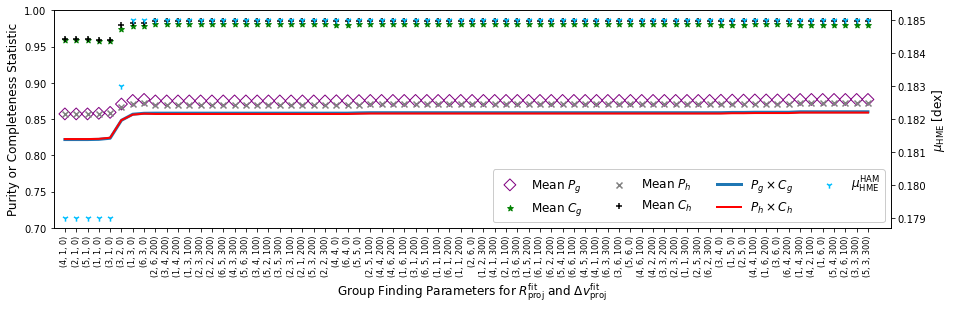

In [9]:
myrange=np.arange(1,len(pg)+1)
fig,ax=plt.subplots(figsize=(15,4))
ax.scatter(myrange-1,pg,edgecolors='purple',facecolors='None',marker='D',label='Mean $P_g$',s=70)
ax.scatter(myrange-1,cg,color='green',marker='*', label='Mean $C_g$')
ax.scatter(myrange-1,ph,color='gray',marker='x', label='Mean $P_h$')
ax.scatter(myrange-1,ch,color='k',marker='+', label='Mean $C_h$',s=30)
ax.plot(myrange-1,pgtimescg,color='tab:blue', linewidth=3,label=r'$P_g \times C_g$')
ax.plot(myrange-1,phtimesch,color='red',linewidth=2, label=r'$P_h \times C_h$')
ax.set_xticks(myrange-1,newlabels, rotation='vertical',fontsize=8)
ax.set_xlabel(r"Group Finding Parameters for $R_{\rm proj}^{\rm fit}$ and $\Delta v_{\rm proj}^{\rm fit}$",fontsize=12)
ax.set_ylim(0.7,1.0)
ax.set_xlim(-1,max(myrange)+1)
ax.set_ylabel("Purity or Completeness Statistic",fontsize=12)
ax1=ax.twinx()
ax1.scatter(myrange-1,mu_phys,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
#ax1.scatter(myrange-1,mu_dyn,marker='2',color='olive')
ax.scatter(-99,-99,marker='1',color='deepskyblue',s=40,label=r'$\mu_{\rm HME}^{\rm HAM}$')
ax1.set_ylabel(r'$\mu_{\rm HME}$ [dex]',fontsize=12)
#ax1.set_ylim(0.15,0.18)
#plt.xlim(50,100)
ax.legend(loc='lower right', framealpha=1, fontsize=12, ncol=4)
plt.show()

In [10]:
mock = pd.read_hdf("../halobiasmocks/fiducial/ECO_cat_0_Planck_memb_cat.hdf5")

In [11]:
mock=mock.groupby('haloid').filter(lambda h: (h.M_r>-19.4).all())
print(len(mock))

8414


In [12]:
grpn=mock.groupby('haloid').size().to_numpy()

In [13]:
grpn

array([1, 1, 1, ..., 3, 1, 1])

In [14]:
grpn>1

array([False, False, False, ...,  True, False, False])

In [15]:
np.sum(_)

723